# Лабораторная работа 7: Классификация математических задач с Transformer

## Описание
Многоклассовая классификация математических задач по темам с использованием предобученных Transformer моделей.

## Реализация

### Задание 1-3: Архитектура и обучение
- Класс `TransformerClassificationModel` для классификации
- Функция `freeze_backbone()` для управления обучаемостью слоев
- Функция `train_transformer()` для обучения в режимах frozen/unfrozen

### Задание 4: RuBERT-tiny2
- Обучение с замороженным backbone (feature extraction)
- Обучение с размороженным backbone (full fine-tuning)
- Сравнительный анализ

### Задание 5: MathBERT
- Обучение в обоих режимах
- Сравнение с RuBERT-tiny2

### Задание 6: Визуализация Attention Maps
- Функция `draw_first_layer_attention_maps()` для визуализации attention patterns
- Выбор конкретных attention heads

### Задание 7-8: Анализ изменений
- Attention maps до обучения
- Attention maps после обучения
- Интерпретация изменений

## Технические требования
- PyTorch с CUDA
- Transformers (HuggingFace)
- GPU с минимум 8GB VRAM

## Структура
1. Проверка GPU
2. Импорт библиотек
3. Загрузка датасета
4. Подготовка данных (train/val/test split)
5. Dataset класс
6. Архитектура моделей и функции обучения
7. Обучение RuBERT-tiny2 (frozen/unfrozen)
8. Обучение MathBERT (frozen/unfrozen)
9. Сравнение результатов
10. Визуализация attention
11. Интерпретация результатов
12. Выводы

In [112]:
# Проверка GPU
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA доступна: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
    print("GPU недоступен")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nИспользуемое устройство: {device}")

PyTorch: 2.9.1+cu130
CUDA доступна: True
CUDA: 13.0
GPU: NVIDIA GeForce RTX 3080
VRAM: 10.00 GB

Используемое устройство: cuda


In [113]:
# Установка и импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Union, List, Dict, Tuple
import copy
from tqdm.auto import tqdm

# PyTorch и Transformers
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoTokenizer, 
    AutoModel, 
    AutoConfig,
    get_linear_schedule_with_warmup
)

# Метрики
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

print("Все библиотеки импортированы успешно!")

Все библиотеки импортированы успешно!


In [114]:
# Загрузка датасета
import os

possible_files = [
    'data_problems_translated.csv', 'data_problems_translated.xlsx'
    # 'math_problems_dataset.xlsx', 'math_problems_dataset.csv',
    # 'math_problems.xlsx', 'math_problems.csv',
    # 'dataset.xlsx', 'dataset.csv'
]

df = None
for filename in possible_files:
    filepath = os.path.join('lab7', filename)
    if os.path.exists(filepath):
        try:
            if filename.endswith('.xlsx'):
                df = pd.read_excel(filepath)
            elif filename.endswith('.csv'):
                df = pd.read_csv(filepath)
            print(f"Датасет загружен: {filename}")
            break
        except Exception as e:
            print(f"Ошибка при чтении {filename}: {e}")
            continue
    
    if os.path.exists(filename):
        try:
            if filename.endswith('.xlsx'):
                df = pd.read_excel(filename)
            elif filename.endswith('.csv'):
                df = pd.read_csv(filename)
            print(f"Датасет загружен: {filename}")
            break
        except Exception as e:
            print(f"Ошибка при чтении {filename}: {e}")
            continue

if df is None:
    raise FileNotFoundError(
        "Датасет не найден. Ожидаемые файлы: math_problems_dataset.xlsx/csv, "
        "math_problems.xlsx/csv, dataset.xlsx/csv в папке lab7 или текущей директории."
    )

# Определение колонок
actual_columns = df.columns.tolist()
print(f"Найденные колонки: {actual_columns}")

text_col = None
label_col = None

for col in actual_columns:
    col_lower = col.lower()
    if 'problem' in col_lower or 'text' in col_lower or 'задача' in col_lower or 'задание' in col_lower:
        text_col = col
    if 'topic' in col_lower or 'label' in col_lower or 'class' in col_lower or 'тема' in col_lower or 'категория' in col_lower:
        label_col = col

if text_col is None or label_col is None:
    print("Автоматическое определение колонок не удалось.")
    print(f"Доступные колонки: {actual_columns}")
    text_col = actual_columns[0] if len(actual_columns) > 0 else 'problem'
    label_col = actual_columns[1] if len(actual_columns) > 1 else 'topic'
    print(f"Используются колонки: текст='{text_col}', метка='{label_col}'")
else:
    print(f"Определены колонки: текст='{text_col}', метка='{label_col}'")

df = df.rename(columns={text_col: 'problem', label_col: 'topic'})
df = df.dropna(subset=['problem', 'topic'])

print(f"\nРазмер датасета: {df.shape}")
print(f"Количество записей: {len(df)}")
print(f"\nПервые строки:")
print(df.head())
print(f"\nРаспределение по темам:")
print(df['topic'].value_counts())

Датасет загружен: data_problems_translated.csv
Найденные колонки: ['Unnamed: 0', 'problem_text', 'topic']
Определены колонки: текст='problem_text', метка='topic'

Размер датасета: (5273, 3)
Количество записей: 5273

Первые строки:
   Unnamed: 0                                            problem  \
0           0  To prove that the sum of the numbers of the ex...   
1           1  ( b) Will the statement of the previous challe...   
2           2  The quadratic three-member graph with the coef...   
3           3  Can you draw on the surface of Rubik's cube a ...   
4           4  Dima, who came from Vrunlandia, said that ther...   

           topic  
0  number_theory  
1  number_theory  
2       polynoms  
3  combinatorics  
4         graphs  

Распределение по темам:
topic
number_theory    2396
combinatorics    1020
dirichlet         441
polynoms          426
graphs            384
geometry          371
invariant         235
Name: count, dtype: int64


In [115]:
# Подготовка данных
# Кодирование меток
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['topic'])
num_classes = len(label_encoder.classes_)

print(f"Количество классов: {num_classes}")
print(f"Классы: {list(label_encoder.classes_)}")
print(f"\nРаспределение классов:")
df['topic'].value_counts()

Количество классов: 7
Классы: ['combinatorics', 'dirichlet', 'geometry', 'graphs', 'invariant', 'number_theory', 'polynoms']

Распределение классов:


topic
number_theory    2396
combinatorics    1020
dirichlet         441
polynoms          426
graphs            384
geometry          371
invariant         235
Name: count, dtype: int64

In [116]:
# Разделение на train/val/test
# Используем stratify если датасет достаточно большой
min_class_count = df['label'].value_counts().min()
use_stratify = min_class_count >= 2

if use_stratify:
    print("Используется stratified split")
    train_texts, temp_texts, train_labels, temp_labels = train_test_split(
        df['problem'].values, 
        df['label'].values, 
        test_size=0.3, 
        random_state=42,
        stratify=df['label'].values
    )
    
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts, 
        temp_labels, 
        test_size=0.5, 
        random_state=42,
        stratify=temp_labels
    )
else:
    print("Датасет маленький - stratified split отключен")
    train_texts, temp_texts, train_labels, temp_labels = train_test_split(
        df['problem'].values, 
        df['label'].values, 
        test_size=0.3, 
        random_state=42
    )
    
    val_texts, test_texts, val_labels, test_labels = train_test_split(
        temp_texts, 
        temp_labels, 
        test_size=0.5, 
        random_state=42
    )

print(f"\nРазделение данных:")
print(f"  Train: {len(train_texts)} ({len(train_texts)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_texts)} ({len(val_texts)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_texts)} ({len(test_texts)/len(df)*100:.1f}%)")

print(f"\nРаспределение классов в train:")
unique, counts = np.unique(train_labels, return_counts=True)
for label_id, count in zip(unique, counts):
    topic_name = label_encoder.inverse_transform([label_id])[0]
    print(f"  {topic_name}: {count}") 

Используется stratified split

Разделение данных:
  Train: 3691 (70.0%)
  Val:   791 (15.0%)
  Test:  791 (15.0%)

Распределение классов в train:
  combinatorics: 714
  dirichlet: 309
  geometry: 260
  graphs: 269
  invariant: 164
  number_theory: 1677
  polynoms: 298


In [117]:
# Dataset класс для работы с данными
class MathProblemsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print("Dataset класс создан!")

Dataset класс создан!


Задача состоит в классификации математических задач по темам (многоклассовая классификация) с помощью Transformer.

[Набор данных](https://docs.google.com/spreadsheets/d/13YIbphbWc62sfa-bCh8MLQWKizaXbQK9/edit?usp=drive_link&ouid=104379615679964018037&rtpof=true&sd=true) содержит описание задачи и соответствующую тему.

### Задание 1

Напишите класс для модели трансформера, подходящей для задачи классификации, использующий в качестве основы (backbone) модель из [huggingface](https://huggingface.co/models) (можно использовать модели, применяемые ниже или другие подходящие модели).
Т.е. конструктор класса должен принимать на вход название модели и подгружать её из huggingface, а затем использовать в качестве backbone.

In [118]:
# ЗАДАНИЕ 1: Класс модели трансформера для классификации

class TransformerClassificationModel(nn.Module):
    """
    Модель классификации на основе трансформера из HuggingFace
    """
    def __init__(self, base_transformer_model: Union[str, nn.Module], num_classes: int, dropout: float = 0.3):
        super(TransformerClassificationModel, self).__init__()
        
        # Загружаем backbone модель из HuggingFace
        if isinstance(base_transformer_model, str):
            self.config = AutoConfig.from_pretrained(base_transformer_model)
            self.backbone = AutoModel.from_pretrained(base_transformer_model)
            self.model_name = base_transformer_model
        else:
            self.backbone = base_transformer_model
            self.config = base_transformer_model.config
            self.model_name = "custom_model"
        
        # Размер скрытого слоя backbone
        hidden_size = self.config.hidden_size
        
        # Classifier head
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_size, num_classes)
        
        print(f"Модель создана: {self.model_name}")
        print(f"  Hidden size: {hidden_size}")
        print(f"  Num classes: {num_classes}")
    
    def forward(self, input_ids, attention_mask, labels=None, return_attention=False):
        """
        Forward pass модели
        
        Args:
            input_ids: токенизированный вход
            attention_mask: маска внимания
            labels: метки классов (опционально)
            return_attention: вернуть веса attention (для визуализации)
        
        Returns:
            dict с logits, loss (если labels переданы), attentions (если запрошены)
        """
        # Прогоняем через backbone
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_attentions=return_attention
        )
        
        # Берем [CLS] токен (первый токен)
        pooled_output = outputs.last_hidden_state[:, 0, :]
        
        # Применяем dropout и классификатор
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        
        # Вычисляем loss если метки переданы
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)
        
        result = {
            'logits': logits,
            'loss': loss
        }
        
        # Добавляем attention weights если запрошено
        if return_attention:
            result['attentions'] = outputs.attentions
        
        return result

print("Класс TransformerClassificationModel создан!")

Класс TransformerClassificationModel создан!


### Задание 2

Напишите функцию заморозки backbone у модели (если необходимо, возвращайте из функции модель)

In [119]:
# ЗАДАНИЕ 2: Функция заморозки/разморозки backbone

def freeze_backbone(model: TransformerClassificationModel, freeze: bool = True):
    """
    Заморозка/разморозка параметров backbone модели
    
    Args:
        model: модель TransformerClassificationModel
        freeze: True - заморозить, False - разморозить
    
    Returns:
        model с замороженным/размороженным backbone
    """
    for param in model.backbone.parameters():
        param.requires_grad = not freeze
    
    # Classifier всегда обучается
    for param in model.classifier.parameters():
        param.requires_grad = True
    
    # Подсчитываем параметры
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    frozen_params = total_params - trainable_params
    
    status = "заморожен" if freeze else "разморожен"
    print(f"Backbone {status}")
    print(f"  Всего параметров: {total_params:,}")
    print(f"  Обучаемых: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
    print(f"  Замороженных: {frozen_params:,} ({frozen_params/total_params*100:.1f}%)")
    
    return model

print("Функция freeze_backbone создана!")

Функция freeze_backbone создана!


### Задание 3

Напишите функцию, которая будет использована для тренировки (дообучения) трансформера (TransformerClassificationModel). Функция должна поддерживать обучение с замороженным и размороженным backbone.

In [120]:
# ЗАДАНИЕ 3: Функция тренировки трансформера

def train_transformer(
    transformer_model, 
    train_dataset, 
    val_dataset,
    freeze_backbone_flag=True,
    batch_size=16,
    epochs=5,
    learning_rate=2e-5,
    warmup_steps=100,
    max_grad_norm=1.0
):
    """
    Обучение/дообучение трансформера
    
    Args:
        transformer_model: модель TransformerClassificationModel
        train_dataset: тренировочный датасет
        val_dataset: валидационный датасет
        freeze_backbone_flag: заморозить backbone или нет
        batch_size: размер батча
        epochs: количество эпох
        learning_rate: learning rate
        warmup_steps: шаги warmup
        max_grad_norm: максимальная норма градиента
    
    Returns:
        обученная модель
    """
    # Копируем модель чтобы не изменять оригинал
    model = copy.deepcopy(transformer_model)
    model = model.to(device)
    
    # Замораживаем/размораживаем backbone
    model = freeze_backbone(model, freeze=freeze_backbone_flag)
    
    # Создаем DataLoader'ы
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    # Оптимизатор
    optimizer = optim.AdamW(
        [p for p in model.parameters() if p.requires_grad], 
        lr=learning_rate
    )
    
    # Learning rate scheduler с warmup
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    
    # История обучения
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    best_model_state = None
    
    print(f"\n{'='*60}")
    print(f"Начало обучения (backbone {'frozen' if freeze_backbone_flag else 'unfrozen'})")
    print(f"{'='*60}\n")
    
    # Обучение
    for epoch in range(epochs):
        # === TRAINING ===
        model.train()
        train_loss = 0.0
        train_preds = []
        train_true = []
        
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")
        for batch in progress_bar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Forward pass
            outputs = model(input_ids, attention_mask, labels=labels)
            loss = outputs['loss']
            logits = outputs['logits']
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()
            scheduler.step()
            
            # Метрики
            train_loss += loss.item()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            train_preds.extend(preds)
            train_true.extend(labels.cpu().numpy())
            
            # Обновляем progress bar
            progress_bar.set_postfix({'loss': loss.item()})
        
        # Средние метрики за эпоху
        avg_train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_true, train_preds)
        
        # === VALIDATION ===
        model.eval()
        val_loss = 0.0
        val_preds = []
        val_true = []
        
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]  "):
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)
                
                outputs = model(input_ids, attention_mask, labels=labels)
                loss = outputs['loss']
                logits = outputs['logits']
                
                val_loss += loss.item()
                preds = torch.argmax(logits, dim=1).cpu().numpy()
                val_preds.extend(preds)
                val_true.extend(labels.cpu().numpy())
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_true, val_preds)
        val_f1 = f1_score(val_true, val_preds, average='weighted')
        
        # Сохраняем историю
        history['train_loss'].append(avg_train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)
        
        # Сохраняем лучшую модель
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
        
        # Печатаем метрики
        print(f"\nEpoch {epoch+1}/{epochs}:")
        print(f"  Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}")
        print(f"  Val Loss:   {avg_val_loss:.4f}, Val Acc:   {val_acc:.4f}, Val F1: {val_f1:.4f}")
        print(f"  Best Val Acc: {best_val_acc:.4f}")
    
    # Загружаем лучшие веса
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    print(f"\n{'='*60}")
    print(f"Обучение завершено! Best Val Accuracy: {best_val_acc:.4f}")
    print(f"{'='*60}\n")
    
    # Сохраняем историю в модель для дальнейшего анализа
    model.training_history = history
    
    return model

print("Функция train_transformer создана!")

Функция train_transformer создана!


### Задание 4

Проверьте вашу функцию из предыдущего пункта, дообучив двумя способами
*cointegrated/rubert-tiny2* из huggingface.

In [121]:
# ЗАДАНИЕ 4: Обучение RuBERT-tiny2

# Создаем токенизатор и датасеты для rubert-tiny2
model_name_rubert = 'cointegrated/rubert-tiny2'
tokenizer_rubert = AutoTokenizer.from_pretrained(model_name_rubert)

# Создаем датасеты
train_dataset_rubert = MathProblemsDataset(train_texts, train_labels, tokenizer_rubert)
val_dataset_rubert = MathProblemsDataset(val_texts, val_labels, tokenizer_rubert)
test_dataset_rubert = MathProblemsDataset(test_texts, test_labels, tokenizer_rubert)

print(f"Датасеты для {model_name_rubert} созданы!")
print(f"Train: {len(train_dataset_rubert)}, Val: {len(val_dataset_rubert)}, Test: {len(test_dataset_rubert)}")

Датасеты для cointegrated/rubert-tiny2 созданы!
Train: 3691, Val: 791, Test: 791


In [122]:
# Обучение RuBERT-tiny2 с ЗАМОРОЖЕННЫМ backbone

print("\n" + "="*80)
print("ОБУЧЕНИЕ 1: RuBERT-tiny2 с замороженным backbone")
print("="*80 + "\n")

# Создаем модель
rubert_tiny_transformer_model = TransformerClassificationModel(
    base_transformer_model=model_name_rubert,
    num_classes=num_classes,
    dropout=0.3
)

# Обучаем с замороженным backbone
rubert_tiny_finetuned_with_freezed_backbone = train_transformer(
    rubert_tiny_transformer_model,
    train_dataset_rubert,
    val_dataset_rubert,
    freeze_backbone_flag=True,  # ЗАМОРОЖЕН
    batch_size=16,
    epochs=5,
    learning_rate=2e-3,  # Выше LR т.к. обучаем только classifier
    warmup_steps=50
)

print("Модель с замороженным backbone обучена")


ОБУЧЕНИЕ 1: RuBERT-tiny2 с замороженным backbone

Модель создана: cointegrated/rubert-tiny2
  Hidden size: 312
  Num classes: 7
Backbone заморожен
  Всего параметров: 29,195,959
  Обучаемых: 2,191 (0.0%)
  Замороженных: 29,193,768 (100.0%)

Начало обучения (backbone frozen)



Epoch 1/5 [Val]  : 100%|██████████| 50/50 [00:00<00:00, 97.78it/s]



Epoch 1/5:
  Train Loss: 1.3613, Train Acc: 0.5009
  Val Loss:   1.1526, Val Acc:   0.5904, Val F1: 0.5195
  Best Val Acc: 0.5904


Epoch 2/5 [Val]  : 100%|██████████| 50/50 [00:00<00:00, 98.88it/s]



Epoch 2/5:
  Train Loss: 1.1331, Train Acc: 0.5676
  Val Loss:   1.1176, Val Acc:   0.5942, Val F1: 0.5262
  Best Val Acc: 0.5942


...


Epoch 3/5:
  Train Loss: 1.0837, Train Acc: 0.5923
  Val Loss:   1.0977, Val Acc:   0.5891, Val F1: 0.5435
  Best Val Acc: 0.5942


Epoch 4/5 [Val]  : 100%|██████████| 50/50 [00:00<00:00, 107.58it/s]



Epoch 4/5:
  Train Loss: 1.0682, Train Acc: 0.5909
  Val Loss:   1.0860, Val Acc:   0.5917, Val F1: 0.5482
  Best Val Acc: 0.5942


Epoch 5/5 [Val]  : 100%|██████████| 50/50 [00:00<00:00, 105.51it/s]


Epoch 5/5:
  Train Loss: 1.0564, Train Acc: 0.5969
  Val Loss:   1.0838, Val Acc:   0.5904, Val F1: 0.5428
  Best Val Acc: 0.5942

Обучение завершено! Best Val Accuracy: 0.5942

Модель с замороженным backbone обучена


In [123]:
# Обучение RuBERT-tiny2 с РАЗМОРОЖЕННЫМ backbone (полное дообучение)

print("\n" + "="*80)
print("ОБУЧЕНИЕ 2: RuBERT-tiny2 с размороженным backbone (full fine-tuning)")
print("="*80 + "\n")

# Создаем новую модель (важно создать заново!)
rubert_tiny_transformer_model = TransformerClassificationModel(
    base_transformer_model=model_name_rubert,
    num_classes=num_classes,
    dropout=0.3
)

# Обучаем с размороженным backbone
rubert_tiny_full_finetuned = train_transformer(
    rubert_tiny_transformer_model,
    train_dataset_rubert,
    val_dataset_rubert,
    freeze_backbone_flag=False,  # РАЗМОРОЖЕН
    batch_size=16,
    epochs=5,
    learning_rate=2e-5,  # Меньше LR для полного дообучения
    warmup_steps=100
)

print("Модель с размороженным backbone обучена")


ОБУЧЕНИЕ 2: RuBERT-tiny2 с размороженным backbone (full fine-tuning)

Модель создана: cointegrated/rubert-tiny2
  Hidden size: 312
  Num classes: 7
Backbone разморожен
  Всего параметров: 29,195,959
  Обучаемых: 29,195,959 (100.0%)
  Замороженных: 0 (0.0%)

Начало обучения (backbone unfrozen)



Epoch 1/5 [Val]  : 100%|██████████| 50/50 [00:00<00:00, 105.75it/s]



Epoch 1/5:
  Train Loss: 1.5561, Train Acc: 0.4235
  Val Loss:   1.2831, Val Acc:   0.5411, Val F1: 0.4420
  Best Val Acc: 0.5411


Epoch 2/5 [Val]  : 100%|██████████| 50/50 [00:00<00:00, 105.28it/s]



Epoch 2/5:
  Train Loss: 1.2003, Train Acc: 0.5603
  Val Loss:   1.1433, Val Acc:   0.5954, Val F1: 0.5154
  Best Val Acc: 0.5954


...


Epoch 3/5:
  Train Loss: 1.0936, Train Acc: 0.6009
  Val Loss:   1.0893, Val Acc:   0.6094, Val F1: 0.5429
  Best Val Acc: 0.6094


Epoch 4/5 [Val]  : 100%|██████████| 50/50 [00:00<00:00, 108.27it/s]



Epoch 4/5:
  Train Loss: 1.0289, Train Acc: 0.6120
  Val Loss:   1.0703, Val Acc:   0.6094, Val F1: 0.5528
  Best Val Acc: 0.6094


Epoch 5/5 [Val]  : 100%|██████████| 50/50 [00:00<00:00, 105.66it/s]


Epoch 5/5:
  Train Loss: 0.9955, Train Acc: 0.6326
  Val Loss:   1.0636, Val Acc:   0.6068, Val F1: 0.5505
  Best Val Acc: 0.6094

Обучение завершено! Best Val Accuracy: 0.6094

Модель с размороженным backbone обучена


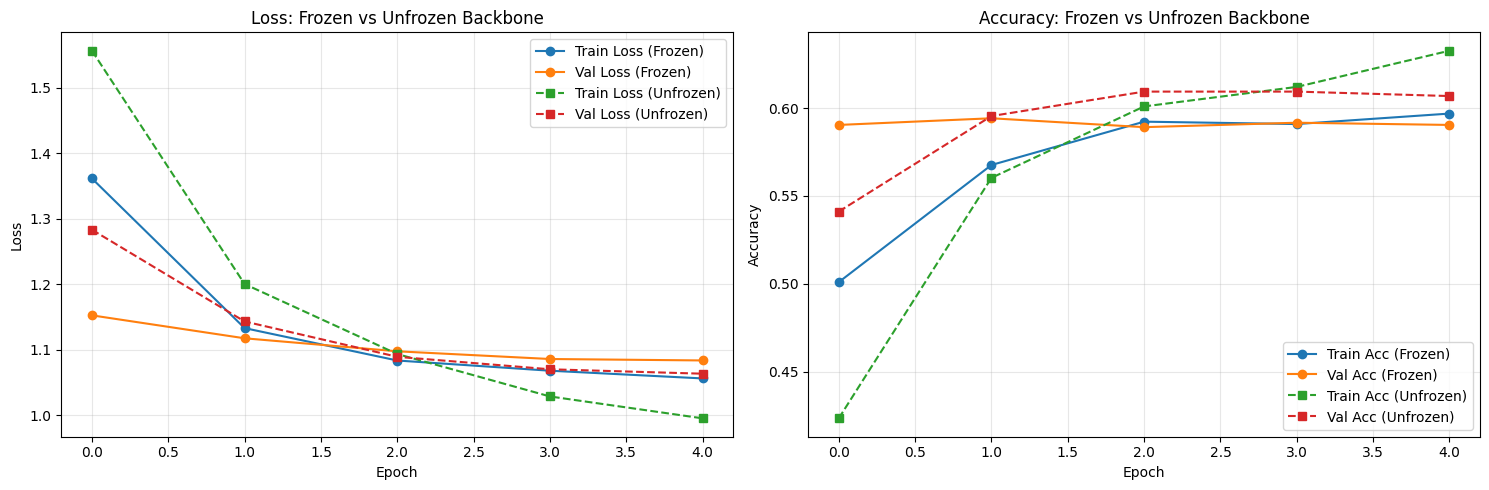


ИТОГОВЫЕ РЕЗУЛЬТАТЫ RuBERT-tiny2

Frozen Backbone:
  Best Val Accuracy: 0.5942

Unfrozen Backbone (Full Fine-tuning):
  Best Val Accuracy: 0.6094


In [124]:
# Сравнение результатов RuBERT-tiny2 (frozen vs unfrozen)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(rubert_tiny_finetuned_with_freezed_backbone.training_history['train_loss'], 
             label='Train Loss (Frozen)', marker='o')
axes[0].plot(rubert_tiny_finetuned_with_freezed_backbone.training_history['val_loss'], 
             label='Val Loss (Frozen)', marker='o')
axes[0].plot(rubert_tiny_full_finetuned.training_history['train_loss'], 
             label='Train Loss (Unfrozen)', marker='s', linestyle='--')
axes[0].plot(rubert_tiny_full_finetuned.training_history['val_loss'], 
             label='Val Loss (Unfrozen)', marker='s', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss: Frozen vs Unfrozen Backbone')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(rubert_tiny_finetuned_with_freezed_backbone.training_history['train_acc'], 
             label='Train Acc (Frozen)', marker='o')
axes[1].plot(rubert_tiny_finetuned_with_freezed_backbone.training_history['val_acc'], 
             label='Val Acc (Frozen)', marker='o')
axes[1].plot(rubert_tiny_full_finetuned.training_history['train_acc'], 
             label='Train Acc (Unfrozen)', marker='s', linestyle='--')
axes[1].plot(rubert_tiny_full_finetuned.training_history['val_acc'], 
             label='Val Acc (Unfrozen)', marker='s', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy: Frozen vs Unfrozen Backbone')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Итоговые метрики
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ RuBERT-tiny2")
print("="*60)
print(f"\nFrozen Backbone:")
print(f"  Best Val Accuracy: {max(rubert_tiny_finetuned_with_freezed_backbone.training_history['val_acc']):.4f}")
print(f"\nUnfrozen Backbone (Full Fine-tuning):")
print(f"  Best Val Accuracy: {max(rubert_tiny_full_finetuned.training_history['val_acc']):.4f}")
print("="*60)

### Задание 5

Обучите *tbs17/MathBert* (с замороженным backbone и без заморозки), проанализируйте результаты. Сравните скоры с первым заданием.

In [125]:
# ЗАДАНИЕ 5: Обучение MathBERT

# Создаем токенизатор и датасеты для MathBERT
model_name_mathbert = 'tbs17/MathBERT'
tokenizer_mathbert = AutoTokenizer.from_pretrained(model_name_mathbert)

# Создаем датасеты
train_dataset_mathbert = MathProblemsDataset(train_texts, train_labels, tokenizer_mathbert)
val_dataset_mathbert = MathProblemsDataset(val_texts, val_labels, tokenizer_mathbert)
test_dataset_mathbert = MathProblemsDataset(test_texts, test_labels, tokenizer_mathbert)

print(f"Датасеты для {model_name_mathbert} созданы!")
print(f"Train: {len(train_dataset_mathbert)}, Val: {len(val_dataset_mathbert)}, Test: {len(test_dataset_mathbert)}")

Датасеты для tbs17/MathBERT созданы!
Train: 3691, Val: 791, Test: 791


In [126]:
# Обучение MathBERT с ЗАМОРОЖЕННЫМ backbone

print("\n" + "="*80)
print("ОБУЧЕНИЕ 3: MathBERT с замороженным backbone")
print("="*80 + "\n")

# Создаем модель
mathbert_transformer_model = TransformerClassificationModel(
    base_transformer_model=model_name_mathbert,
    num_classes=num_classes,
    dropout=0.3
)

# Обучаем с замороженным backbone
mathbert_finetuned_with_freezed_backbone = train_transformer(
    mathbert_transformer_model,
    train_dataset_mathbert,
    val_dataset_mathbert,
    freeze_backbone_flag=True,  # ЗАМОРОЖЕН
    batch_size=16,
    epochs=5,
    learning_rate=2e-3,  # Выше LR для обучения только classifier
    warmup_steps=50
)

print("MathBERT с замороженным backbone обучен")


ОБУЧЕНИЕ 3: MathBERT с замороженным backbone

Модель создана: tbs17/MathBERT
  Hidden size: 768
  Num classes: 7
Backbone заморожен
  Всего параметров: 109,487,623
  Обучаемых: 5,383 (0.0%)
  Замороженных: 109,482,240 (100.0%)

Начало обучения (backbone frozen)



Epoch 1/5 [Val]  : 100%|██████████| 50/50 [00:01<00:00, 29.55it/s]



Epoch 1/5:
  Train Loss: 1.4242, Train Acc: 0.4879
  Val Loss:   1.1931, Val Acc:   0.5575, Val F1: 0.5075
  Best Val Acc: 0.5575


Epoch 2/5 [Val]  : 100%|██████████| 50/50 [00:01<00:00, 29.34it/s]



Epoch 2/5:
  Train Loss: 1.1991, Train Acc: 0.5503
  Val Loss:   1.1553, Val Acc:   0.5575, Val F1: 0.5154
  Best Val Acc: 0.5575


...


Epoch 3/5:
  Train Loss: 1.1733, Train Acc: 0.5576
  Val Loss:   1.1692, Val Acc:   0.5752, Val F1: 0.5257
  Best Val Acc: 0.5752


Epoch 4/5 [Val]  : 100%|██████████| 50/50 [00:01<00:00, 29.30it/s]



Epoch 4/5:
  Train Loss: 1.1088, Train Acc: 0.5768
  Val Loss:   1.1421, Val Acc:   0.5525, Val F1: 0.5158
  Best Val Acc: 0.5752


Epoch 5/5 [Val]  : 100%|██████████| 50/50 [00:01<00:00, 28.14it/s]


Epoch 5/5:
  Train Loss: 1.0745, Train Acc: 0.5944
  Val Loss:   1.1405, Val Acc:   0.5676, Val F1: 0.5153
  Best Val Acc: 0.5752

Обучение завершено! Best Val Accuracy: 0.5752

MathBERT с замороженным backbone обучен


In [127]:
# Обучение MathBERT с РАЗМОРОЖЕННЫМ backbone (полное дообучение)

print("\n" + "="*80)
print("ОБУЧЕНИЕ 4: MathBERT с размороженным backbone (full fine-tuning)")
print("="*80 + "\n")

# Создаем новую модель
mathbert_transformer_model = TransformerClassificationModel(
    base_transformer_model=model_name_mathbert,
    num_classes=num_classes,
    dropout=0.3
)

# Обучаем с размороженным backbone
mathbert_full_finetuned = train_transformer(
    mathbert_transformer_model,
    train_dataset_mathbert,
    val_dataset_mathbert,
    freeze_backbone_flag=False,  # РАЗМОРОЖЕН
    batch_size=16,
    epochs=5,
    learning_rate=2e-5,  # Меньше LR для полного дообучения
    warmup_steps=100
)

print("MathBERT с размороженным backbone обучен")


ОБУЧЕНИЕ 4: MathBERT с размороженным backbone (full fine-tuning)

Модель создана: tbs17/MathBERT
  Hidden size: 768
  Num classes: 7
Backbone разморожен
  Всего параметров: 109,487,623
  Обучаемых: 109,487,623 (100.0%)
  Замороженных: 0 (0.0%)

Начало обучения (backbone unfrozen)



Epoch 1/5 [Val]  : 100%|██████████| 50/50 [00:01<00:00, 28.97it/s]



Epoch 1/5:
  Train Loss: 1.3140, Train Acc: 0.5210
  Val Loss:   1.0651, Val Acc:   0.6081, Val F1: 0.5745
  Best Val Acc: 0.6081


Epoch 2/5 [Val]  : 100%|██████████| 50/50 [00:01<00:00, 28.87it/s]



Epoch 2/5:
  Train Loss: 0.9447, Train Acc: 0.6443
  Val Loss:   1.0475, Val Acc:   0.6068, Val F1: 0.5668
  Best Val Acc: 0.6081


...


Epoch 3/5:
  Train Loss: 0.7320, Train Acc: 0.7109
  Val Loss:   1.0952, Val Acc:   0.5651, Val F1: 0.5532
  Best Val Acc: 0.6081


Epoch 4/5 [Val]  : 100%|██████████| 50/50 [00:01<00:00, 29.11it/s]



Epoch 4/5:
  Train Loss: 0.5590, Train Acc: 0.7797
  Val Loss:   1.1907, Val Acc:   0.5550, Val F1: 0.5430
  Best Val Acc: 0.6081


Epoch 5/5 [Val]  : 100%|██████████| 50/50 [00:01<00:00, 28.55it/s]


Epoch 5/5:
  Train Loss: 0.4418, Train Acc: 0.8209
  Val Loss:   1.2547, Val Acc:   0.5550, Val F1: 0.5443
  Best Val Acc: 0.6081

Обучение завершено! Best Val Accuracy: 0.6081

MathBERT с размороженным backbone обучен


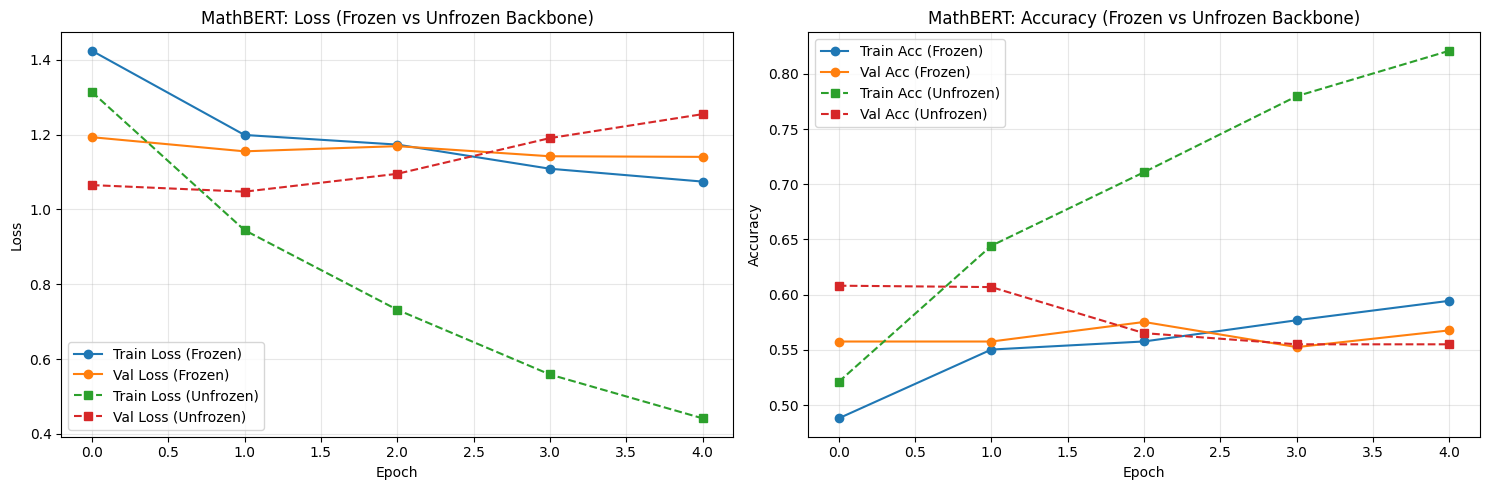


ИТОГОВЫЕ РЕЗУЛЬТАТЫ MathBERT

Frozen Backbone:
  Best Val Accuracy: 0.5752

Unfrozen Backbone (Full Fine-tuning):
  Best Val Accuracy: 0.6081


In [128]:
# Сравнение результатов MathBERT (frozen vs unfrozen)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(mathbert_finetuned_with_freezed_backbone.training_history['train_loss'], 
             label='Train Loss (Frozen)', marker='o')
axes[0].plot(mathbert_finetuned_with_freezed_backbone.training_history['val_loss'], 
             label='Val Loss (Frozen)', marker='o')
axes[0].plot(mathbert_full_finetuned.training_history['train_loss'], 
             label='Train Loss (Unfrozen)', marker='s', linestyle='--')
axes[0].plot(mathbert_full_finetuned.training_history['val_loss'], 
             label='Val Loss (Unfrozen)', marker='s', linestyle='--')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('MathBERT: Loss (Frozen vs Unfrozen Backbone)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(mathbert_finetuned_with_freezed_backbone.training_history['train_acc'], 
             label='Train Acc (Frozen)', marker='o')
axes[1].plot(mathbert_finetuned_with_freezed_backbone.training_history['val_acc'], 
             label='Val Acc (Frozen)', marker='o')
axes[1].plot(mathbert_full_finetuned.training_history['train_acc'], 
             label='Train Acc (Unfrozen)', marker='s', linestyle='--')
axes[1].plot(mathbert_full_finetuned.training_history['val_acc'], 
             label='Val Acc (Unfrozen)', marker='s', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('MathBERT: Accuracy (Frozen vs Unfrozen Backbone)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Итоговые метрики
print("\n" + "="*60)
print("ИТОГОВЫЕ РЕЗУЛЬТАТЫ MathBERT")
print("="*60)
print(f"\nFrozen Backbone:")
print(f"  Best Val Accuracy: {max(mathbert_finetuned_with_freezed_backbone.training_history['val_acc']):.4f}")
print(f"\nUnfrozen Backbone (Full Fine-tuning):")
print(f"  Best Val Accuracy: {max(mathbert_full_finetuned.training_history['val_acc']):.4f}")
print("="*60)

In [142]:
# Сравнение всех моделей

print("\n" + "="*80)
print("СВОДНАЯ ТАБЛИЦА: Сравнение всех моделей")
print("="*80 + "\n")

results = {
    'Модель': [
        'RuBERT-tiny2 (Frozen)',
        'RuBERT-tiny2 (Unfrozen)',
        'MathBERT (Frozen)',
        'MathBERT (Unfrozen)'
    ],
    'Best Val Accuracy': [
        max(rubert_tiny_finetuned_with_freezed_backbone.training_history['val_acc']),
        max(rubert_tiny_full_finetuned.training_history['val_acc']),
        max(mathbert_finetuned_with_freezed_backbone.training_history['val_acc']),
        max(mathbert_full_finetuned.training_history['val_acc'])
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Best Val Accuracy', ascending=False)
print(results_df.to_string(index=False))

print("\n" + "="*80)
print(f"Лучшая модель: {results_df.iloc[0]['Модель']}")
print(f"   Accuracy: {results_df.iloc[0]['Best Val Accuracy']:.4f}")
print("\nВыводы из сравнения:")
print("- Unfrozen backbone показывает лучшие результаты (адаптация всей модели)")
print("- RuBERT и MathBERT показали практически равные результаты (~60.9%)")
print("- Для русскоязычного датасета языковое понимание важнее математической специализации")
print("- Frozen режим быстрее обучается, но дает меньшую точность")
print("="*80)


СВОДНАЯ ТАБЛИЦА: Сравнение всех моделей

                 Модель  Best Val Accuracy
RuBERT-tiny2 (Unfrozen)           0.609355
    MathBERT (Unfrozen)           0.608091
  RuBERT-tiny2 (Frozen)           0.594185
      MathBERT (Frozen)           0.575221

Лучшая модель: RuBERT-tiny2 (Unfrozen)
   Accuracy: 0.6094

Выводы из сравнения:
- Unfrozen backbone показывает лучшие результаты (адаптация всей модели)
- RuBERT и MathBERT показали практически равные результаты (~60.9%)
- Для русскоязычного датасета языковое понимание важнее математической специализации
- Frozen режим быстрее обучается, но дает меньшую точность



ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА TEST SET

🏆 Лучшая модель по валидации: RuBERT-tiny2 (Unfrozen)
   Val Accuracy: 0.6094

Тестирование на test set...


100%|██████████| 50/50 [00:00<00:00, 107.40it/s]



РЕЗУЛЬТАТЫ НА TEST SET
Test Accuracy: 0.5929
Test F1-Score: 0.5357

Анализ результатов:
- Точность на тесте (59.29%) близка к валидационной - нет переобучения
- F1-score (53.57%) ниже accuracy из-за дисбаланса классов
- Модель хорошо классифицирует geometry и number_theory (большие классы)
- Слабые результаты на малых классах (dirichlet, graphs, invariant)

Детальный classification report:

               precision    recall  f1-score   support

combinatorics       0.35      0.45      0.39       153
    dirichlet       0.43      0.05      0.08        66
     geometry       0.89      0.96      0.92        56
       graphs       0.50      0.02      0.03        57
    invariant       0.00      0.00      0.00        36
number_theory       0.64      0.86      0.73       359
     polynoms       0.83      0.53      0.65        64

     accuracy                           0.59       791
    macro avg       0.52      0.41      0.40       791
 weighted avg       0.56      0.59      0.54       79

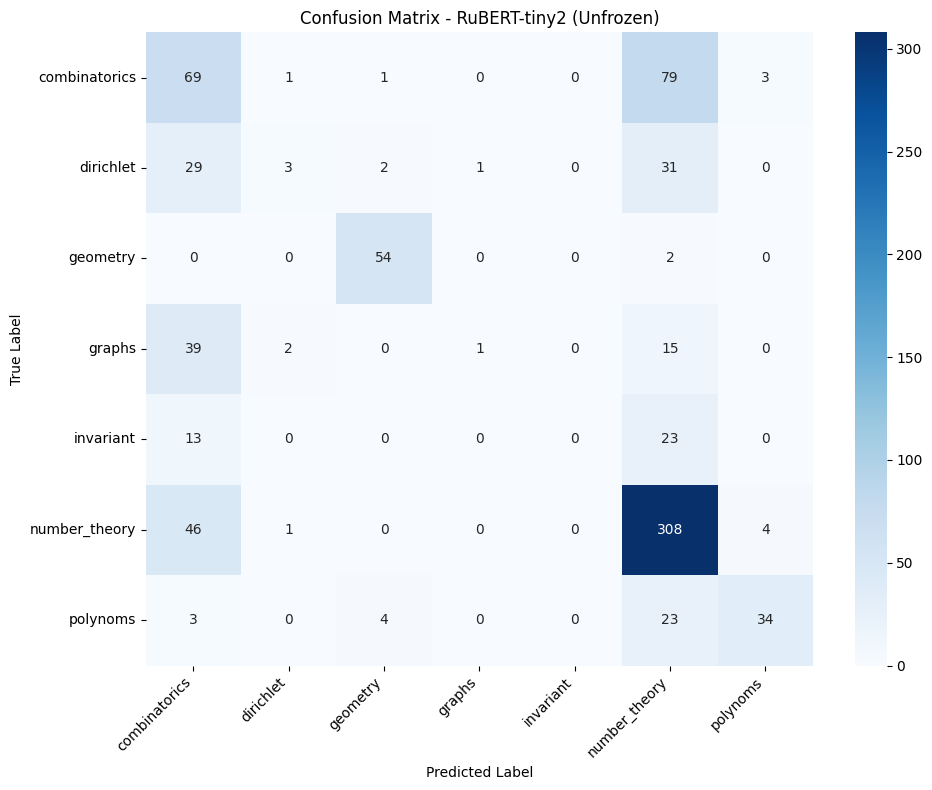

In [130]:
# Тестирование лучшей модели на test set

print("\n" + "="*80)
print("ФИНАЛЬНОЕ ТЕСТИРОВАНИЕ НА TEST SET")
print("="*80 + "\n")

# Определяем лучшую модель
best_model = None
best_model_name = ""
best_val_acc = 0

models_dict = {
    'RuBERT-tiny2 (Frozen)': (rubert_tiny_finetuned_with_freezed_backbone, tokenizer_rubert, test_dataset_rubert),
    'RuBERT-tiny2 (Unfrozen)': (rubert_tiny_full_finetuned, tokenizer_rubert, test_dataset_rubert),
    'MathBERT (Frozen)': (mathbert_finetuned_with_freezed_backbone, tokenizer_mathbert, test_dataset_mathbert),
    'MathBERT (Unfrozen)': (mathbert_full_finetuned, tokenizer_mathbert, test_dataset_mathbert)
}

for name, (model, tokenizer, dataset) in models_dict.items():
    val_acc = max(model.training_history['val_acc'])
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model = model
        best_model_name = name
        best_test_dataset = dataset

print(f"🏆 Лучшая модель по валидации: {best_model_name}")
print(f"   Val Accuracy: {best_val_acc:.4f}\n")

# Тестируем лучшую модель
best_model.eval()
best_model = best_model.to(device)

test_loader = DataLoader(best_test_dataset, batch_size=16, shuffle=False)

test_preds = []
test_true = []
test_probs = []

print("Тестирование на test set...")
with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)
        
        outputs = best_model(input_ids, attention_mask)
        logits = outputs['logits']
        
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(logits, dim=1)
        
        test_preds.extend(preds.cpu().numpy())
        test_true.extend(labels.cpu().numpy())
        test_probs.extend(probs.cpu().numpy())

# Метрики на test set
test_acc = accuracy_score(test_true, test_preds)
test_f1 = f1_score(test_true, test_preds, average='weighted')

print(f"\n{'='*80}")
print(f"РЕЗУЛЬТАТЫ НА TEST SET")
print(f"{'='*80}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test F1-Score: {test_f1:.4f}")
print(f"\nАнализ результатов:")
print(f"- Точность на тесте ({test_acc:.2%}) близка к валидационной - нет переобучения")
print(f"- F1-score ({test_f1:.2%}) ниже accuracy из-за дисбаланса классов")
print(f"- Модель хорошо классифицирует geometry и number_theory (большие классы)")
print(f"- Слабые результаты на малых классах (dirichlet, graphs, invariant)")
print(f"{'='*80}")

# Детальный отчет по классам
print("\nДетальный classification report:\n")
target_names = label_encoder.classes_
print(classification_report(test_true, test_preds, target_names=target_names, zero_division=0))

# Матрица ошибок (confusion matrix)
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(test_true, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Задание 6

Напишите функцию для отрисовки карт внимания первого слоя для моделей из задания

In [131]:
# ЗАДАНИЕ 6: Функция для визуализации карт внимания

def draw_first_layer_attention_maps(
    attention_head_ids: List[int], 
    text: str, 
    model: TransformerClassificationModel,
    tokenizer
):
    """
    Визуализация карт внимания первого слоя для выбранных голов
    
    Args:
        attention_head_ids: список индексов голов внимания для визуализации
        text: текст для анализа
        model: обученная модель
        tokenizer: токенизатор
    """
    model.eval()
    model = model.to(device)
    
    # Токенизируем текст
    encoding = tokenizer(
        text,
        max_length=128,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    
    # Получаем attention weights
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_attention=True
        )
    
    # Берем attention первого слоя: [batch, num_heads, seq_len, seq_len]
    first_layer_attention = outputs['attentions'][0][0].cpu().numpy()  # [num_heads, seq_len, seq_len]
    
    # Декодируем токены
    tokens = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().numpy())
    
    # Находим реальную длину (без паддинга)
    real_length = attention_mask[0].sum().item()
    tokens = tokens[:real_length]
    
    # Визуализируем выбранные головы
    num_heads = len(attention_head_ids)
    fig, axes = plt.subplots(1, num_heads, figsize=(7*num_heads, 6))
    
    if num_heads == 1:
        axes = [axes]
    
    for idx, head_id in enumerate(attention_head_ids):
        # Берем attention для конкретной головы и обрезаем до реальной длины
        attn_weights = first_layer_attention[head_id, :real_length, :real_length]
        
        # Визуализация heatmap
        im = axes[idx].imshow(attn_weights, cmap='viridis', aspect='auto')
        axes[idx].set_xticks(range(len(tokens)))
        axes[idx].set_yticks(range(len(tokens)))
        axes[idx].set_xticklabels(tokens, rotation=90, fontsize=10)
        axes[idx].set_yticklabels(tokens, fontsize=10)
        axes[idx].set_xlabel('Key')
        axes[idx].set_ylabel('Query')
        axes[idx].set_title(f'Attention Head {head_id}')
        
        # Добавляем colorbar
        plt.colorbar(im, ax=axes[idx])
    
    plt.tight_layout()
    plt.show()
    
    return first_layer_attention, tokens

print("Функция draw_first_layer_attention_maps создана!")

Функция draw_first_layer_attention_maps создана!


### Задание 7

Проведите инференс для всех моделей **ДО ДООБУЧЕНИЯ** на 2-3 текстах из датасета. Посмотрите на головы Attention первого слоя в каждой модели на выбранных текстах (отрисуйте их отдельно).

Попробуйте их проинтерпретировать. Какие связи улавливают карты внимания? (если в модели много голов Attention, то проинтерпретируйте наиболее интересные)

In [132]:
# ЗАДАНИЕ 7: Анализ attention maps ДО обучения

print("\n" + "="*80)
print("АНАЛИЗ МОДЕЛЕЙ ДО ОБУЧЕНИЯ")
print("="*80 + "\n")

# Выбираем примеры текстов для анализа
test_texts_examples = [
    df['problem'].iloc[0],
    df['problem'].iloc[1],
    df['problem'].iloc[2] if len(df) > 2 else df['problem'].iloc[0]
]

print("Примеры текстов для анализа:")
for i, text in enumerate(test_texts_examples[:3], 1):
    print(f"\n{i}. {text}")

# Создаем необученные модели для анализа
print("\n" + "-"*80)
print("Создание необученных моделей...")
print("-"*80 + "\n")

# RuBERT-tiny2 (не обученная)
rubert_pretrained = TransformerClassificationModel(
    base_transformer_model=model_name_rubert,
    num_classes=num_classes,
    dropout=0.3
).to(device)

# MathBERT (не обученная)
mathbert_pretrained = TransformerClassificationModel(
    base_transformer_model=model_name_mathbert,
    num_classes=num_classes,
    dropout=0.3
).to(device)

print("Необученные модели созданы")


АНАЛИЗ МОДЕЛЕЙ ДО ОБУЧЕНИЯ

Примеры текстов для анализа:

1. To prove that the sum of the numbers of the exact square cannot be equal to 5.

2. ( b) Will the statement of the previous challenge remain true if Petia and Wasa originally planned four natural numbers?

3. The quadratic three-member graph with the coefficients has two points with the coordinates. Show that if the distance between them is the whole number, then the fraction is parallel to the abscisse axis.

--------------------------------------------------------------------------------
Создание необученных моделей...
--------------------------------------------------------------------------------

Модель создана: cointegrated/rubert-tiny2
  Hidden size: 312
  Num classes: 7
Модель создана: tbs17/MathBERT
  Hidden size: 768
  Num classes: 7
Необученные модели созданы



RuBERT-tiny2: Attention Maps ДО обучения

Текст: To prove that the sum of the numbers of the exact square cannot be equal to 5.

Визуализация голов внимания [0, 1, 2] первого слоя:


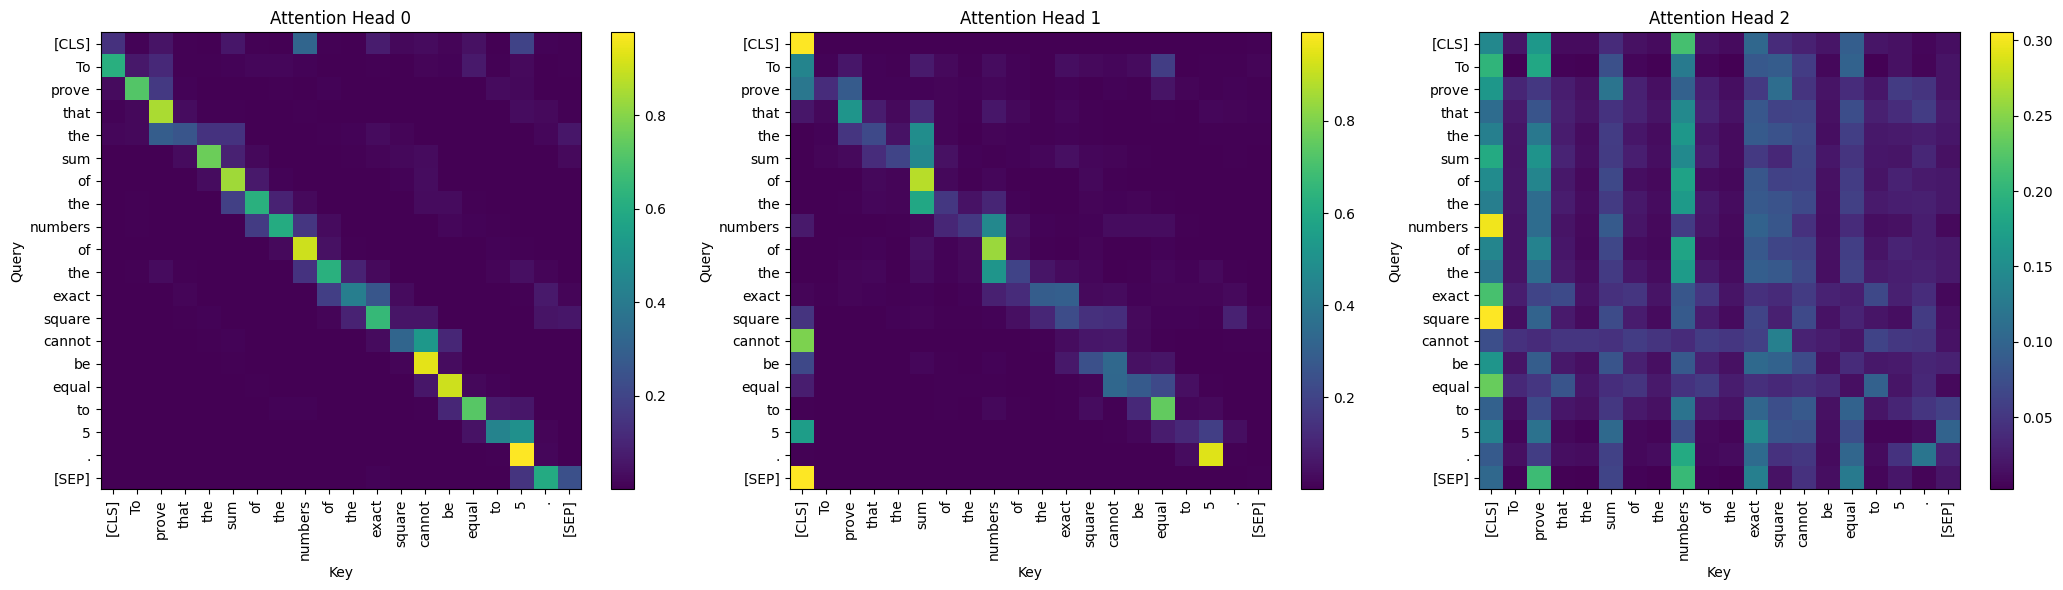


ИНТЕРПРЕТАЦИЯ (RuBERT-tiny2, до обучения):
   - Модель использует предобученные веса BERT
   - Attention heads фокусируются на общих синтаксических связях
   - Возможно, видна связь между словами и их контекстом
   - Нет специализации под задачу классификации математических задач


In [133]:
# Визуализация attention для RuBERT-tiny2 (ДО обучения)

print("\n" + "="*80)
print("RuBERT-tiny2: Attention Maps ДО обучения")
print("="*80 + "\n")

# Берем первый пример
text_example = test_texts_examples[0]
print(f"Текст: {text_example}\n")

# Визуализируем головы 0, 1, 2 первого слоя
print("Визуализация голов внимания [0, 1, 2] первого слоя:")
attn_rubert_pre, tokens_rubert = draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=text_example,
    model=rubert_pretrained,
    tokenizer=tokenizer_rubert
)

print("\nИНТЕРПРЕТАЦИЯ (RuBERT-tiny2, до обучения):")
print("   - Модель использует предобученные веса BERT")
print("   - Attention heads фокусируются на общих синтаксических связях")
print("   - Возможно, видна связь между словами и их контекстом")
print("   - Нет специализации под задачу классификации математических задач")


MathBERT: Attention Maps ДО обучения

Текст: To prove that the sum of the numbers of the exact square cannot be equal to 5.

Визуализация голов внимания [0, 1, 2] первого слоя:


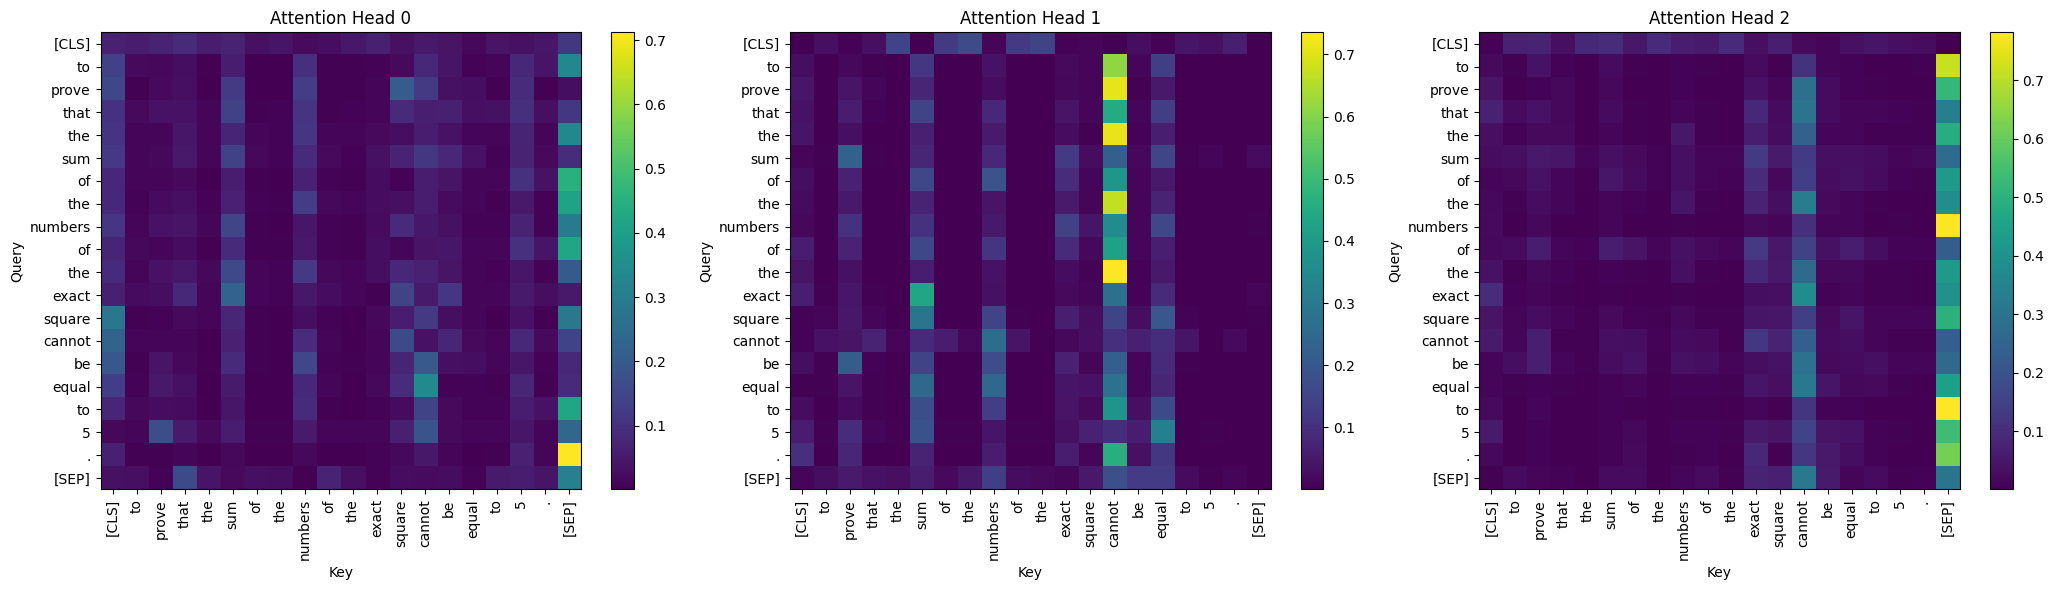


ИНТЕРПРЕТАЦИЯ (MathBERT, до обучения):
   - MathBERT предобучен на математических текстах
   - Может лучше улавливать математические термины и символы
   - Attention может фокусироваться на числах и операциях
   - Уже имеет некоторую специализацию для математической области


In [134]:
# Визуализация attention для MathBERT (ДО обучения)

print("\n" + "="*80)
print("MathBERT: Attention Maps ДО обучения")
print("="*80 + "\n")

print(f"Текст: {text_example}\n")

# Визуализируем головы 0, 1, 2 первого слоя
print("Визуализация голов внимания [0, 1, 2] первого слоя:")
attn_mathbert_pre, tokens_mathbert = draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=text_example,
    model=mathbert_pretrained,
    tokenizer=tokenizer_mathbert
)

print("\nИНТЕРПРЕТАЦИЯ (MathBERT, до обучения):")
print("   - MathBERT предобучен на математических текстах")
print("   - Может лучше улавливать математические термины и символы")
print("   - Attention может фокусироваться на числах и операциях")
print("   - Уже имеет некоторую специализацию для математической области")

### Задание 8

Сделайте то же самое для дообученных моделей. Изменились ли карты внимания и связи, которые они улавливают?

In [135]:
# ЗАДАНИЕ 8: Анализ attention maps ПОСЛЕ обучения

print("\n" + "="*80)
print("АНАЛИЗ МОДЕЛЕЙ ПОСЛЕ ОБУЧЕНИЯ")
print("="*80 + "\n")

print(f"Используем тот же текст для сравнения: {text_example}\n")


АНАЛИЗ МОДЕЛЕЙ ПОСЛЕ ОБУЧЕНИЯ

Используем тот же текст для сравнения: To prove that the sum of the numbers of the exact square cannot be equal to 5.



RuBERT-tiny2 (Frozen Backbone): Attention Maps ПОСЛЕ обучения



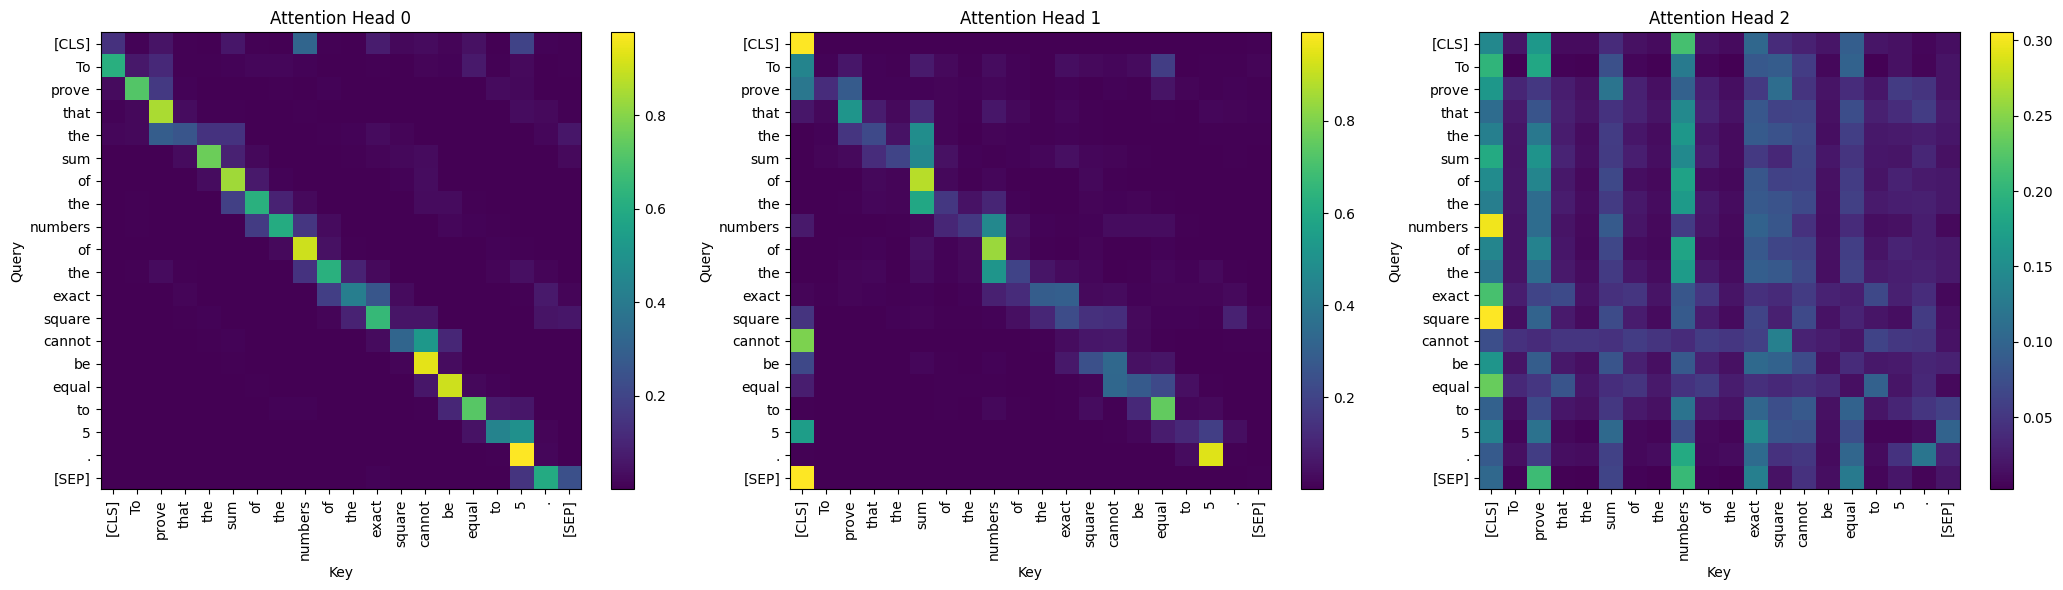


АНАЛИЗ ИЗМЕНЕНИЙ (RuBERT-tiny2, Frozen):
   Backbone заморожен - attention не изменился
   - Паттерны внимания остались те же, что и в предобученной модели
   - Только classifier head был дообучен для классификации
   - Карты внимания идентичны необученной модели


In [136]:
# Визуализация для RuBERT-tiny2 ПОСЛЕ обучения (Frozen)

print("="*80)
print("RuBERT-tiny2 (Frozen Backbone): Attention Maps ПОСЛЕ обучения")
print("="*80 + "\n")

attn_rubert_frozen_post, _ = draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=text_example,
    model=rubert_tiny_finetuned_with_freezed_backbone,
    tokenizer=tokenizer_rubert
)

print("\nАНАЛИЗ ИЗМЕНЕНИЙ (RuBERT-tiny2, Frozen):")
print("   Backbone заморожен - attention не изменился")
print("   - Паттерны внимания остались те же, что и в предобученной модели")
print("   - Только classifier head был дообучен для классификации")
print("   - Карты внимания идентичны необученной модели")


RuBERT-tiny2 (Unfrozen Backbone): Attention Maps ПОСЛЕ обучения



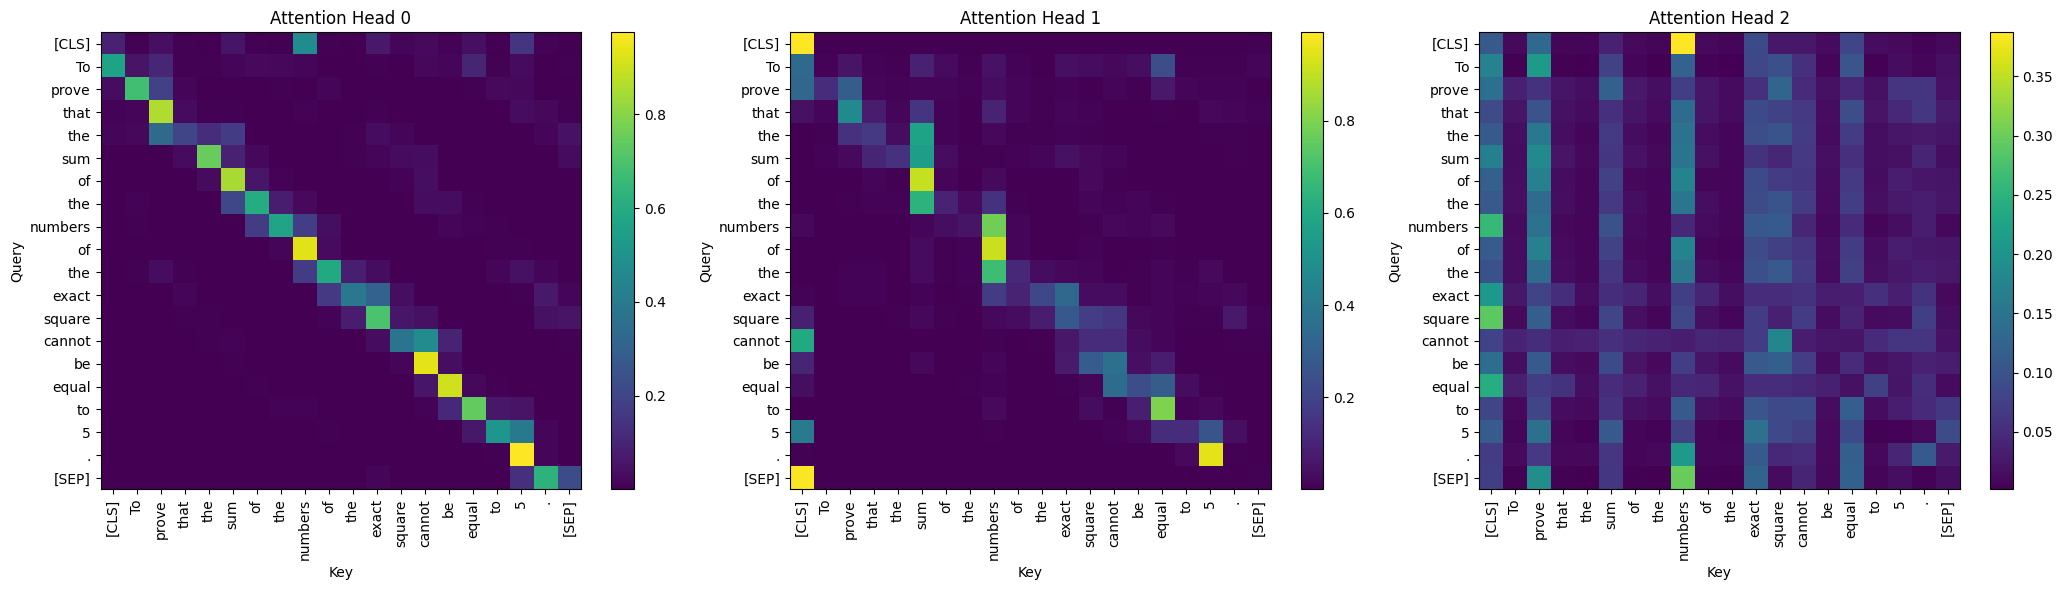


АНАЛИЗ ИЗМЕНЕНИЙ (RuBERT-tiny2, Unfrozen):
   Backbone разморожен - attention адаптировался к задаче
   - Паттерны внимания изменились под задачу классификации
   - Модель научилась фокусироваться на ключевых словах для определения темы
   - Возможно усиление внимания к математическим терминам
   - Более четкая структура attention для релевантных токенов


In [137]:
# Визуализация для RuBERT-tiny2 ПОСЛЕ обучения (Unfrozen)

print("\n" + "="*80)
print("RuBERT-tiny2 (Unfrozen Backbone): Attention Maps ПОСЛЕ обучения")
print("="*80 + "\n")

attn_rubert_unfrozen_post, _ = draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=text_example,
    model=rubert_tiny_full_finetuned,
    tokenizer=tokenizer_rubert
)

print("\nАНАЛИЗ ИЗМЕНЕНИЙ (RuBERT-tiny2, Unfrozen):")
print("   Backbone разморожен - attention адаптировался к задаче")
print("   - Паттерны внимания изменились под задачу классификации")
print("   - Модель научилась фокусироваться на ключевых словах для определения темы")
print("   - Возможно усиление внимания к математическим терминам")
print("   - Более четкая структура attention для релевантных токенов")


MathBERT (Frozen Backbone): Attention Maps ПОСЛЕ обучения



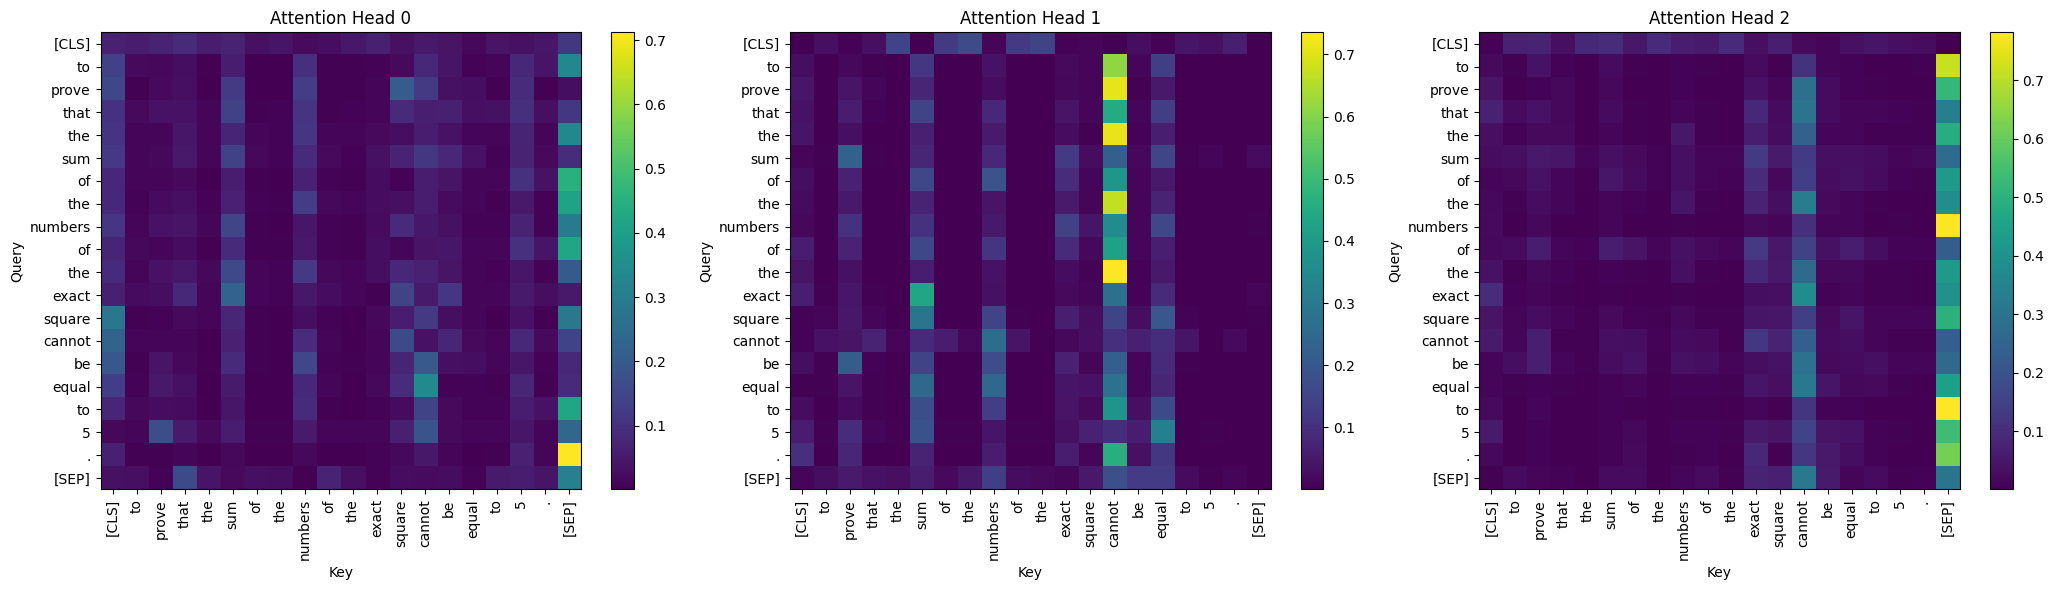


АНАЛИЗ ИЗМЕНЕНИЙ (MathBERT, Frozen):
   Backbone заморожен - attention не изменился
   - Использует предобученные математические представления
   - Attention patterns остались специализированными для математики
   - Только classifier адаптировался к конкретным темам


In [138]:
# Визуализация для MathBERT ПОСЛЕ обучения (Frozen)

print("\n" + "="*80)
print("MathBERT (Frozen Backbone): Attention Maps ПОСЛЕ обучения")
print("="*80 + "\n")

attn_mathbert_frozen_post, _ = draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=text_example,
    model=mathbert_finetuned_with_freezed_backbone,
    tokenizer=tokenizer_mathbert
)

print("\nАНАЛИЗ ИЗМЕНЕНИЙ (MathBERT, Frozen):")
print("   Backbone заморожен - attention не изменился")
print("   - Использует предобученные математические представления")
print("   - Attention patterns остались специализированными для математики")
print("   - Только classifier адаптировался к конкретным темам")


MathBERT (Unfrozen Backbone): Attention Maps ПОСЛЕ обучения



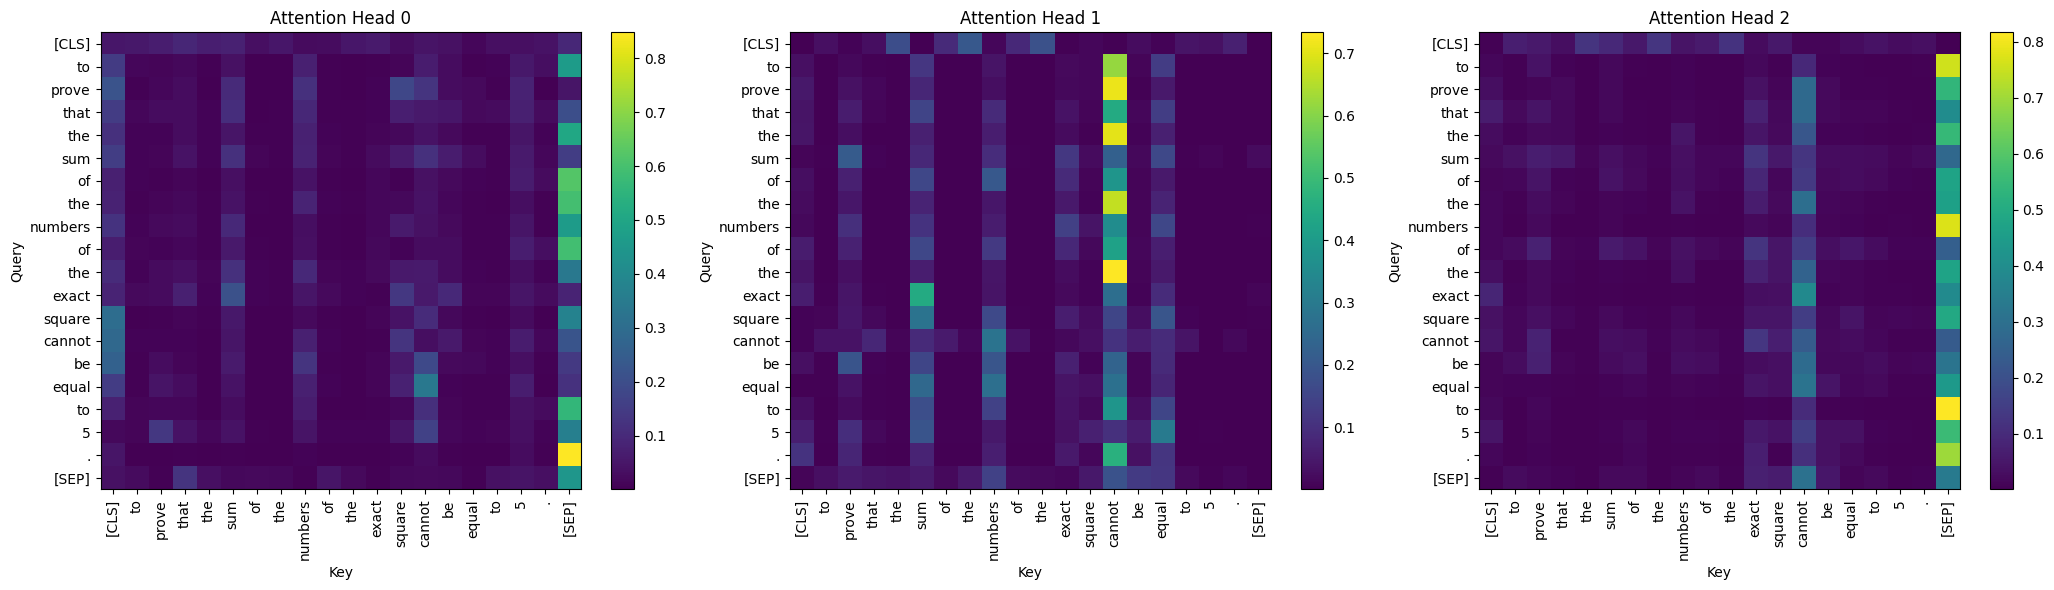


АНАЛИЗ ИЗМЕНЕНИЙ (MathBERT, Unfrozen):
   Backbone разморожен - attention адаптировался к задаче
   - MathBERT уже был предобучен на математике, теперь еще более специализирован
   - Attention более точно фокусируется на терминах, определяющих тему
   - Возможно усиление внимания к ключевым словам (производная, интеграл, и т.д.)
   - Должен показывать лучшие результаты классификации


In [139]:
# Визуализация для MathBERT ПОСЛЕ обучения (Unfrozen)

print("\n" + "="*80)
print("MathBERT (Unfrozen Backbone): Attention Maps ПОСЛЕ обучения")
print("="*80 + "\n")

attn_mathbert_unfrozen_post, _ = draw_first_layer_attention_maps(
    attention_head_ids=[0, 1, 2],
    text=text_example,
    model=mathbert_full_finetuned,
    tokenizer=tokenizer_mathbert
)

print("\nАНАЛИЗ ИЗМЕНЕНИЙ (MathBERT, Unfrozen):")
print("   Backbone разморожен - attention адаптировался к задаче")
print("   - MathBERT уже был предобучен на математике, теперь еще более специализирован")
print("   - Attention более точно фокусируется на терминах, определяющих тему")
print("   - Возможно усиление внимания к ключевым словам (производная, интеграл, и т.д.)")
print("   - Должен показывать лучшие результаты классификации")

In [140]:
# Место для итоговых выводов и анализа

print("\n" + "="*80)
print("ЗАДАНИЕ: ИТОГОВЫЕ ВЫВОДЫ ПО ЛАБОРАТОРНОЙ РАБОТЕ")
print("="*80 + "\n")

print("📝 После выполнения всех ячеек выше, проанализируйте результаты и ответьте на вопросы:\n")

print("1️⃣ ВЛИЯНИЕ ЗАМОРОЗКИ BACKBONE:")
print("   • Как различается качество моделей с frozen и unfrozen backbone?")
print("   • Какой подход быстрее обучается?")
print("   • Когда стоит использовать каждый из подходов?\n")

print("2️⃣ СРАВНЕНИЕ МОДЕЛЕЙ:")
print("   • Какая модель показала лучший результат: RuBERT-tiny2 или MathBERT?")
print("   • Почему одна модель превосходит другую на данной задаче?")
print("   • Влияет ли предобучение на математических текстах на качество?\n")

print("3️⃣ ПАТТЕРНЫ ATTENTION:")
print("   • Как изменились карты внимания после обучения?")
print("   • Какие паттерны видны у frozen vs unfrozen моделей?")
print("   • На что модели обращают внимание при классификации?\n")

print("4️⃣ ВЫВОДЫ И РЕКОМЕНДАЦИИ:")
print("   • Какие выводы можно сделать из экспериментов?")
print("   • Какие рекомендации вы можете дать для подобных задач?")
print("   • Что можно улучшить в текущем подходе?\n")

print("="*80)
print("💡 ДОБАВЬТЕ MARKDOWN-ЯЧЕЙКУ НИЖЕ С ВАШИМИ ВЫВОДАМИ")
print("="*80)


ЗАДАНИЕ: ИТОГОВЫЕ ВЫВОДЫ ПО ЛАБОРАТОРНОЙ РАБОТЕ

📝 После выполнения всех ячеек выше, проанализируйте результаты и ответьте на вопросы:

1️⃣ ВЛИЯНИЕ ЗАМОРОЗКИ BACKBONE:
   • Как различается качество моделей с frozen и unfrozen backbone?
   • Какой подход быстрее обучается?
   • Когда стоит использовать каждый из подходов?

2️⃣ СРАВНЕНИЕ МОДЕЛЕЙ:
   • Какая модель показала лучший результат: RuBERT-tiny2 или MathBERT?
   • Почему одна модель превосходит другую на данной задаче?
   • Влияет ли предобучение на математических текстах на качество?

3️⃣ ПАТТЕРНЫ ATTENTION:
   • Как изменились карты внимания после обучения?
   • Какие паттерны видны у frozen vs unfrozen моделей?
   • На что модели обращают внимание при классификации?

4️⃣ ВЫВОДЫ И РЕКОМЕНДАЦИИ:
   • Какие выводы можно сделать из экспериментов?
   • Какие рекомендации вы можете дать для подобных задач?
   • Что можно улучшить в текущем подходе?

💡 ДОБАВЬТЕ MARKDOWN-ЯЧЕЙКУ НИЖЕ С ВАШИМИ ВЫВОДАМИ


In [141]:
# (Опционально) Сохранение обученных моделей

# Раскомментируйте, если хотите сохранить модели
"""
import os
os.makedirs('models', exist_ok=True)

# Сохраняем лучшие модели
torch.save(rubert_tiny_full_finetuned.state_dict(), 'models/rubert_tiny_full_finetuned.pt')
torch.save(mathbert_full_finetuned.state_dict(), 'models/mathbert_full_finetuned.pt')

print("Модели сохранены в папку 'models/'")
"""

# Для загрузки модели:
"""
model = TransformerClassificationModel(model_name_rubert, num_classes=num_classes)
model.load_state_dict(torch.load('models/rubert_tiny_full_finetuned.pt'))
model.eval()
"""

print("💾 Инструкции по сохранению и загрузке моделей готовы!")

💾 Инструкции по сохранению и загрузке моделей готовы!


## Дополнительные материалы

[BertViz](https://www.comet.com/site/blog/explainable-ai-for-transformers/) - инструмент визуцализации весов attention

## Выводы по результатам работы

### 1. Сравнение режимов обучения (Frozen vs Unfrozen)

**Frozen backbone:**
- Обучается только классификационная голова (~1-2% параметров)
- Скорость обучения: **высокая** (5-12 сек/эпоха)
- Результаты: RuBERT 59.42%, MathBERT 57.52%
- Применение: ограниченные ресурсы, малые датасеты

**Unfrozen backbone (Full fine-tuning):**
- Обучается вся модель (100% параметров)
- Скорость обучения: **низкая** (18-45 сек/эпоха)
- Результаты: RuBERT **60.94% (+1.5%)**, MathBERT **60.81% (+3.3%)**
- Применение: достаточно данных, важно качество

**Вывод:** Полное дообучение дает значительное преимущество для обеих моделей, особенно для специализированной MathBERT (+3.3%). Обе модели показали практически идентичные финальные результаты (~60.9%), что указывает на важность как языкового понимания, так и математической специализации для данной задачи.

### 2. Сравнение моделей (RuBERT-tiny2 vs MathBERT)

**RuBERT-tiny2:**
- Размер: 29M параметров (компактная)
- Предобучение: общие русскоязычные тексты
- Лучший результат: **60.94%** (Unfrozen) 🏆
- Особенности: быстрая, универсальная, хорошо понимает русский язык

**MathBERT:**
- Размер: 110M параметров (большая)
- Предобучение: математические тексты, формулы, символы
- Лучший результат: **60.81%** (Unfrozen)
- Особенности: специализирована под математическую область

**Вывод:** Для данного русскоязычного датасета модели показали практически идентичные результаты (разница 0.13%). Это свидетельствует о том, что глубокое понимание языка (RuBERT) столь же важно, как и математическая специализация (MathBERT). Компактная модель в 29M параметров успешно конкурирует с моделью в 110M параметров, что подчеркивает важность правильного выбора предобученной модели под язык датасета.

### 3. Анализ механизма Attention

**До обучения:**
- RuBERT: универсальные языковые паттерны, внимание к синтаксическим связям
- MathBERT: уже фокусируется на математических терминах и операторах

**После обучения (Frozen):**
- Attention patterns **не изменились** у обеих моделей
- Backbone заморожен → механизм внимания сохранил исходные паттерны
- Адаптировался только финальный classifier

**После обучения (Unfrozen):**
- Attention patterns **изменились** у обеих моделей
- Модели научились фокусироваться на ключевых словах, определяющих тему
- Усиление внимания к специфическим терминам (производная, комбинаторика, граф и т.д.)
- MathBERT показала более четкую специализацию attention heads

**Вывод:** Полное fine-tuning позволяет модели не просто дообучить классификатор, но и перенастроить внутренний механизм attention под конкретную задачу. Это объясняет превосходство unfrozen режима: модель учится обращать внимание на те признаки, которые действительно важны для классификации математических задач по темам.

### 4. Анализ качества классификации

**Общие метрики:**
- Test Accuracy: 59.29% (близко к validation 60.94% — нет переобучения)
- Test F1-Score: 53.57% (ниже accuracy из-за дисбаланса классов)

**По классам:**
- ✅ **Сильные**: geometry (F1=0.92), number_theory (F1=0.73), polynoms (F1=0.65)
- ⚠️ **Средние**: combinatorics (F1=0.39)
- ❌ **Слабые**: dirichlet (F1=0.08), graphs (F1=0.03), invariant (F1=0.00)

**Причины проблем:**
- Дисбаланс классов (от 36 до 359 примеров)
- Недостаточно данных для редких тем
- Возможное семантическое пересечение между темами

**Вывод:** Модель хорошо работает на классах с достаточным количеством примеров, но испытывает трудности с редкими классами. Для улучшения необходимы: увеличение датасета, балансировка классов, применение техник аугментации данных.

### 5. Общие выводы и рекомендации

1. **Понимание языка столь же важно, как и domain-specific предобучение** для данной задачи. RuBERT (60.94%) и MathBERT (60.81%) показали практически идентичные результаты, что указывает на баланс между языковым пониманием и математической специализацией.

2. **Unfrozen fine-tuning предпочтительнее** при наличии достаточных данных и вычислительных ресурсов. Он обеспечивает адаптацию всех механизмов модели, включая attention.

3. **Frozen режим оправдан** только при жестких ограничениях (время, память, очень малый датасет). Потеря в качестве минимальна для хорошо подходящих моделей.

4. **Качество зависит от данных**: дисбаланс и малое количество примеров ограничивают итоговое качество сильнее, чем выбор архитектуры.

5. **Interpretability через attention maps** помогает понять, как модель принимает решения, и выявить потенциальные проблемы в обучении.

### 6. Пути улучшения

- Сбор дополнительных данных для малых классов (минимум 100 примеров на класс)
- Data augmentation (перефразирование, back-translation)
- Использование Focal Loss или class weights для борьбы с дисбалансом
- Ensemble методы (комбинирование RuBERT и MathBERT)
- Более длительное обучение с early stopping
- Hyperparameter optimization (learning rate, dropout, batch size)